# Firing rate maps (per-trajectory, not pooled)

Computes occupancy and firing-rate maps for one neuron at a time, separately for each of the 50 trajectories.

Design notes (fixes vs. the original pipeline):
- Occupancy map and firing-rate map are built with the *same* `np.histogram2d` call signature (same `bins`, same fixed `range`), so they always land on an identical grid — no separate meshgrid/nearest-bin search, no row/column mismatch possible.
- Bin edges are pinned explicitly to the known trajectory bounds `[0, 1] x [0, 1]` via `range=`, instead of being derived from each call's own data min/max — every trajectory's map is on the exact same physical grid, so maps are directly comparable across trials.
- No `rotate()` calls anywhere. The only reorientation is a single `.T` + `origin='lower'` applied consistently at plot time (see `plot_random_trajectory_maps`), so there's nothing that can drift out of sync between maps.
- Activation values are converted to amplitude (`np.abs`) before binning, so complex-valued activity from the oscillatory network is handled explicitly rather than silently truncated by an implicit complex-to-real cast.
- Firing rate = occupancy-weighted mean amplitude per bin (a spatial average), not a threshold-then-peak value — avoids an arbitrary spike threshold and matches how rate maps are usually computed for continuous-valued unit activity.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.ndimage import gaussian_filter
import scipy.signal

In [110]:
# Trajectory grid bounds and map resolution.
# 1000 points per trajectory / 32x32 bins ~= 1 raw sample per bin before smoothing —
# fine enough to resolve field structure without every bin being empty.
BOUNDS = (0.0, 1.0)
N_BINS = 32
SIGMA = 1.0     # Gaussian smoothing bandwidth, in bins
EPS = 1e-10

### Input

In [111]:
def get_input_data(pkl_path, layer_name="d3"):
    """
    Loads trajectory-results.pkl.

    Returns
    -------
    ground_truth : (n_traj, T, 2)
        Ground-truth trajectories.

    prediction : (n_traj, T, 2)
        Predicted trajectories.

    positions : (n_traj, T, 2)
        Positions used for occupancy and firing-rate maps.
        (Currently set to the predicted trajectories.)

    activations : (n_traj, T, n_neurons)
        Neural activations for the selected layer.
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])
    prediction = np.asarray(data["prediction"])
    activations = np.asarray(data[layer_name])

    # Keep only x,y if additional channels exist
    if ground_truth.shape[-1] > 2:
        ground_truth = ground_truth[..., :2]

    if prediction.shape[-1] > 2:
        prediction = prediction[..., :2]

    # Use predicted trajectory for occupancy and firing-rate maps
    positions = prediction.copy()

    return ground_truth, prediction, positions, activations

### Mapping functions

In [112]:
def occupancy_map_func(positions, bins=N_BINS, bounds=BOUNDS, sigma=SIGMA):
    '''
    positions: (T, 2) single trajectory.
    Returns a smoothed occupancy-count map, shape (bins, bins), axis 0 = x-bin, axis 1 = y-bin.
    '''
    H, xedges, yedges = np.histogram2d(
        positions[:, 0], positions[:, 1],
        bins=bins, range=[bounds, bounds]
    )
    occupancy = gaussian_filter(H, sigma=sigma)
    return occupancy, xedges, yedges

In [113]:
def firing_rate_map_func(positions, activity, occupancy_map, bins=N_BINS, bounds=BOUNDS, sigma=SIGMA, eps=EPS):
    '''
    positions: (T, 2) single trajectory.
    activity:  (T,) one neuron's activation for that same trajectory (real or complex).
    occupancy_map: output of occupancy_map_func for this same trajectory (same bins/bounds/sigma).
    Returns the occupancy-normalized firing-rate map, shape (bins, bins), same x/y-bin
    convention as occupancy_map since both come from the same histogram2d(bins=, range=) call.
    '''
    amplitude = np.abs(activity)

    activity_sum, _, _ = np.histogram2d(
        positions[:, 0], positions[:, 1],
        bins=bins, range=[bounds, bounds],
        weights=amplitude
    )
    activity_sum = gaussian_filter(activity_sum, sigma=sigma)

    rate_map = activity_sum / (occupancy_map + eps)
    return rate_map

In [114]:
def firing_rate_maps_for_neuron(positions, activations, neuron_idx, bins=N_BINS, bounds=BOUNDS, sigma=SIGMA, eps=EPS):
    '''
    positions:   (n_traj, T, 2)
    activations: (n_traj, T, n_neurons)
    Computes one occupancy map + one firing-rate map per trajectory (not pooled).
    Returns firing_maps, occupancy_maps, each shape (n_traj, bins, bins).
    '''
    n_traj = positions.shape[0]
    firing_maps = np.zeros((n_traj, bins, bins))
    occupancy_maps = np.zeros((n_traj, bins, bins))

    for t in range(n_traj):
        occ_map, _, _ = occupancy_map_func(positions[t], bins=bins, bounds=bounds, sigma=sigma)
        fr_map = firing_rate_map_func(
            positions[t], activations[t, :, neuron_idx], occ_map,
            bins=bins, bounds=bounds, sigma=sigma, eps=eps
        )
        occupancy_maps[t] = occ_map
        firing_maps[t] = fr_map

    return firing_maps, occupancy_maps

### Plotting

In [115]:
def plot_random_trajectory_maps(firing_maps, neuron_idx, n_show=6, bounds=BOUNDS, seed=None):
    '''
    Plots the firing-rate map for n_show randomly chosen trajectories, for one neuron.
    firing_maps: (n_traj, bins, bins) as returned by firing_rate_maps_for_neuron.
    '''
    rng = np.random.default_rng(seed)
    n_traj = firing_maps.shape[0]
    n_show = min(n_show, n_traj)
    chosen = rng.choice(n_traj, size=n_show, replace=False)

    ncols = min(3, n_show)
    nrows = int(np.ceil(n_show / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

    for ax, traj_idx in zip(axes.ravel(), chosen):
        # firing_maps[traj_idx] is indexed [x_bin, y_bin]; transpose + origin='lower'
        # displays x horizontal and y vertical-increasing-upward, applied identically every time.
        im = ax.imshow(
            firing_maps[traj_idx].T, origin='lower',
            extent=[bounds[0], bounds[1], bounds[0], bounds[1]],
            cmap='jet', aspect='auto'
        )
        ax.set_title(f'Trial {traj_idx}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        fig.colorbar(im, ax=ax, shrink=0.8)

    for ax in axes.ravel()[len(chosen):]:
        ax.axis('off')

    fig.suptitle(f'Neuron {neuron_idx} — firing rate maps ({n_show} random trials)')
    plt.tight_layout()
    plt.show()

In [116]:
from matplotlib.gridspec import GridSpec

def plot_two_random_trajectories(
    ground_truth,
    prediction,
    positions,
    activations,
    neuron_idx,
    bins=N_BINS,
    bounds=BOUNDS,
    sigma=SIGMA,
    seed=None,
):

    rng = np.random.default_rng(seed)
    traj_ids = rng.choice(len(positions), 2, replace=False)

    # -------------------------------------------------------
    # Figure layout
    # -------------------------------------------------------

    fig = plt.figure(figsize=(13, 13), constrained_layout=True)

    gs = GridSpec(
        3,
        3,
        figure=fig,
        width_ratios=[1, 1, 0.05],
        height_ratios=[1, 1, 1],
    )

    axes = np.empty((3, 2), dtype=object)

    axes[0,0] = fig.add_subplot(gs[0,0])
    axes[0,1] = fig.add_subplot(gs[0,1])

    axes[1,0] = fig.add_subplot(gs[1,0])
    axes[1,1] = fig.add_subplot(gs[1,1])

    axes[2,0] = fig.add_subplot(gs[2,0])
    axes[2,1] = fig.add_subplot(gs[2,1])

    cax_occ = fig.add_subplot(gs[1,2])
    cax_fr  = fig.add_subplot(gs[2,2])

    occ_images = []
    fr_images = []

    # -------------------------------------------------------
    # Loop over two trajectories
    # -------------------------------------------------------

    for col, traj in enumerate(traj_ids):

        gt = ground_truth[traj]
        pred = prediction[traj]

        #######################################################
        # Row 1 : Trajectory
        #######################################################

        ax = axes[0, col]

        ax.plot(
            gt[:,0],
            gt[:,1],
            lw=2,
            color="tab:blue",
            label="Ground Truth",
        )

        ax.plot(
            pred[:,0],
            pred[:,1],
            "--",
            lw=2,
            color="tab:red",
            label="Prediction",
        )

        ax.scatter(
            gt[0,0],
            gt[0,1],
            s=90,
            color="limegreen",
            edgecolor="black",
            zorder=5,
            label="Start",
        )

        ax.scatter(
            gt[-1,0],
            gt[-1,1],
            s=110,
            color="black",
            marker="X",
            zorder=5,
            label="End",
        )

        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

        ax.set_aspect("equal", adjustable="box")

        ax.set_xlabel("x")
        ax.set_ylabel("y")

        ax.grid(alpha=0.3)

        ax.set_title(f"Trajectory {traj}")

        if col == 0:
            ax.legend()

        #######################################################
        # Row 2 : Occupancy
        #######################################################

        occ_map, _, _ = occupancy_map_func(
            positions[traj],
            bins=bins,
            bounds=bounds,
            sigma=sigma,
        )

        ax = axes[1, col]

        occ_im = ax.imshow(
            occ_map.T,
            origin="lower",
            extent=[
                bounds[0],
                bounds[1],
                bounds[0],
                bounds[1],
            ],
            cmap="viridis",
            aspect="equal",
        )

        occ_images.append(occ_im)

        ax.set_title("Occupancy Map")

        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

        ax.set_xlabel("x")
        ax.set_ylabel("y")

        ax.set_aspect("equal", adjustable="box")

        #######################################################
        # Row 3 : Firing Rate
        #######################################################

        fr_map = firing_rate_map_func(
            positions[traj],
            activations[traj,:,neuron_idx],
            occ_map,
            bins=bins,
            bounds=bounds,
            sigma=sigma,
        )

        ax = axes[2, col]

        fr_im = ax.imshow(
            fr_map.T,
            origin="lower",
            extent=[
                bounds[0],
                bounds[1],
                bounds[0],
                bounds[1],
            ],
            cmap="jet",
            aspect="equal",
        )

        fr_images.append(fr_im)

        ax.set_title(f"Neuron {neuron_idx}")

        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

        ax.set_xlabel("x")
        ax.set_ylabel("y")

        ax.set_aspect("equal", adjustable="box")

    # -------------------------------------------------------
    # Shared colorbars
    # -------------------------------------------------------

    cb1 = fig.colorbar(
        occ_images[0],
        cax=cax_occ,
    )
    cb1.set_label("Occupancy")

    cb2 = fig.colorbar(
        fr_images[0],
        cax=cax_fr,
    )
    cb2.set_label("Firing Rate")

    fig.suptitle(
        f"Neuron {neuron_idx}: Random Trajectory Comparison",
        fontsize=18,
    )

    plt.show()

In [117]:
def compute_all_neuron_maps(
    positions,
    activations,
    traj_idx,
    bins=N_BINS,
    bounds=BOUNDS,
    sigma=SIGMA,
):
    """
    Compute firing-rate maps for every neuron for one trajectory.

    Returns
    -------
    firing_maps : (n_neurons, bins, bins)
    occupancy_map : (bins, bins)
    """

    occ_map, _, _ = occupancy_map_func(
        positions[traj_idx],
        bins=bins,
        bounds=bounds,
        sigma=sigma,
    )

    n_neurons = activations.shape[-1]

    firing_maps = np.zeros((n_neurons, bins, bins))

    for neuron in range(n_neurons):

        firing_maps[neuron] = firing_rate_map_func(
            positions[traj_idx],
            activations[traj_idx, :, neuron],
            occ_map,
            bins=bins,
            bounds=bounds,
            sigma=sigma,
        )

    return firing_maps, occ_map

In [118]:
def compute_all_neuron_maps(
    positions,
    activations,
    traj_idx,
    bins=N_BINS,
    bounds=BOUNDS,
    sigma=SIGMA,
):
    """
    Computes firing-rate maps for every neuron for one trajectory.

    Parameters
    ----------
    positions : (n_traj, T, 2)
    activations : (n_traj, T, n_neurons)

    Returns
    -------
    firing_maps : (n_neurons, bins, bins)
    occupancy_map : (bins, bins)
    """

    occ_map, _, _ = occupancy_map_func(
        positions[traj_idx],
        bins=bins,
        bounds=bounds,
        sigma=sigma,
    )

    n_neurons = activations.shape[-1]

    firing_maps = np.zeros((n_neurons, bins, bins))

    for neuron in range(n_neurons):

        firing_maps[neuron] = firing_rate_map_func(
            positions[traj_idx],
            activations[traj_idx, :, neuron],
            occ_map,
            bins=bins,
            bounds=bounds,
            sigma=sigma,
        )

    return firing_maps, occ_map

In [119]:
def plot_neuron_grid(
    firing_maps,
    layer_name,
    traj_idx,
    bounds=BOUNDS,
):
    """
    Plot firing maps for all neurons.

    firing_maps:
        (50, bins, bins)
    """

    n_neurons = firing_maps.shape[0]

    nrows = 5
    ncols = 10

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(18, 9),
        constrained_layout=True,
    )

    vmax = np.max(firing_maps)

    for neuron, ax in enumerate(axes.ravel()):

        if neuron >= n_neurons:
            ax.axis("off")
            continue

        im = ax.imshow(
            firing_maps[neuron].T,
            origin="lower",
            extent=[
                bounds[0],
                bounds[1],
                bounds[0],
                bounds[1],
            ],
            cmap="jet",
            vmin=0,
            vmax=vmax,
            aspect="equal",
        )

        ax.set_title(
            f"N{neuron}",
            fontsize=8,
        )

        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        f"Trajectory {traj_idx}   |   Layer {layer_name}",
        fontsize=18,
    )

    cbar = fig.colorbar(
        im,
        ax=axes,
        shrink=0.85,
        pad=0.02,
    )

    cbar.set_label("Firing Rate")

    plt.show()

In [120]:
def plot_all_layers_for_trajectory(
    pkl_path,
    traj_idx,
):
    """
    Creates one 5x10 figure for every layer
    for a single trajectory.
    """

    layers = [
        "d1",
        "z1",
        "d2",
        "z2",
        "d3",
        "z3",
        "d4",
    ]

    for layer in layers:

        _, _, positions, activations = get_input_data(
            pkl_path,
            layer_name=layer,
        )

        firing_maps, _ = compute_all_neuron_maps(
            positions,
            activations,
            traj_idx,
        )

        plot_neuron_grid(
            firing_maps,
            layer,
            traj_idx,
        )

In [121]:
def plot_all_layers_two_trajectories(
    pkl_path,
    traj_ids,
):
    """
    Creates neuron grids for every layer
    for every trajectory in traj_ids.
    """

    for traj in traj_ids:

        print(f"\nTrajectory {traj}")

        plot_all_layers_for_trajectory(
            pkl_path,
            traj,
        )

### Example usage

In [122]:

layer_name = "d4"

pkl_path = "/Users/ais/Desktop/2026_Summer copy/2d_hippocampal_cells/2D-place-grid-cells/2D-traj-results.pkl"

ground_truth, prediction, positions, activations = get_input_data(
    pkl_path,
    layer_name=layer_name
)

print("Ground truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)


Ground truth : (50, 500, 2)
Prediction   : (50, 500, 2)
Positions    : (50, 500, 2)
Activations  : (50, 500, 100)


In [123]:
print(positions.shape)
# (50, 1000, 2)

print(activations.shape)
# (50, 1000, 50)

(50, 500, 2)
(50, 500, 100)


In [124]:
print(positions[10].shape)
# (1000, 2)

print(activations[10].shape)
# (1000, 50)

(500, 2)
(500, 100)


In [125]:
print(firing_maps.shape)
# (50, 32, 32)

print(occupancy_maps.shape)
# (50, 32, 32)

(50, 40, 40)
(50, 40, 40)


In [126]:
traj_ids = [4, 38]

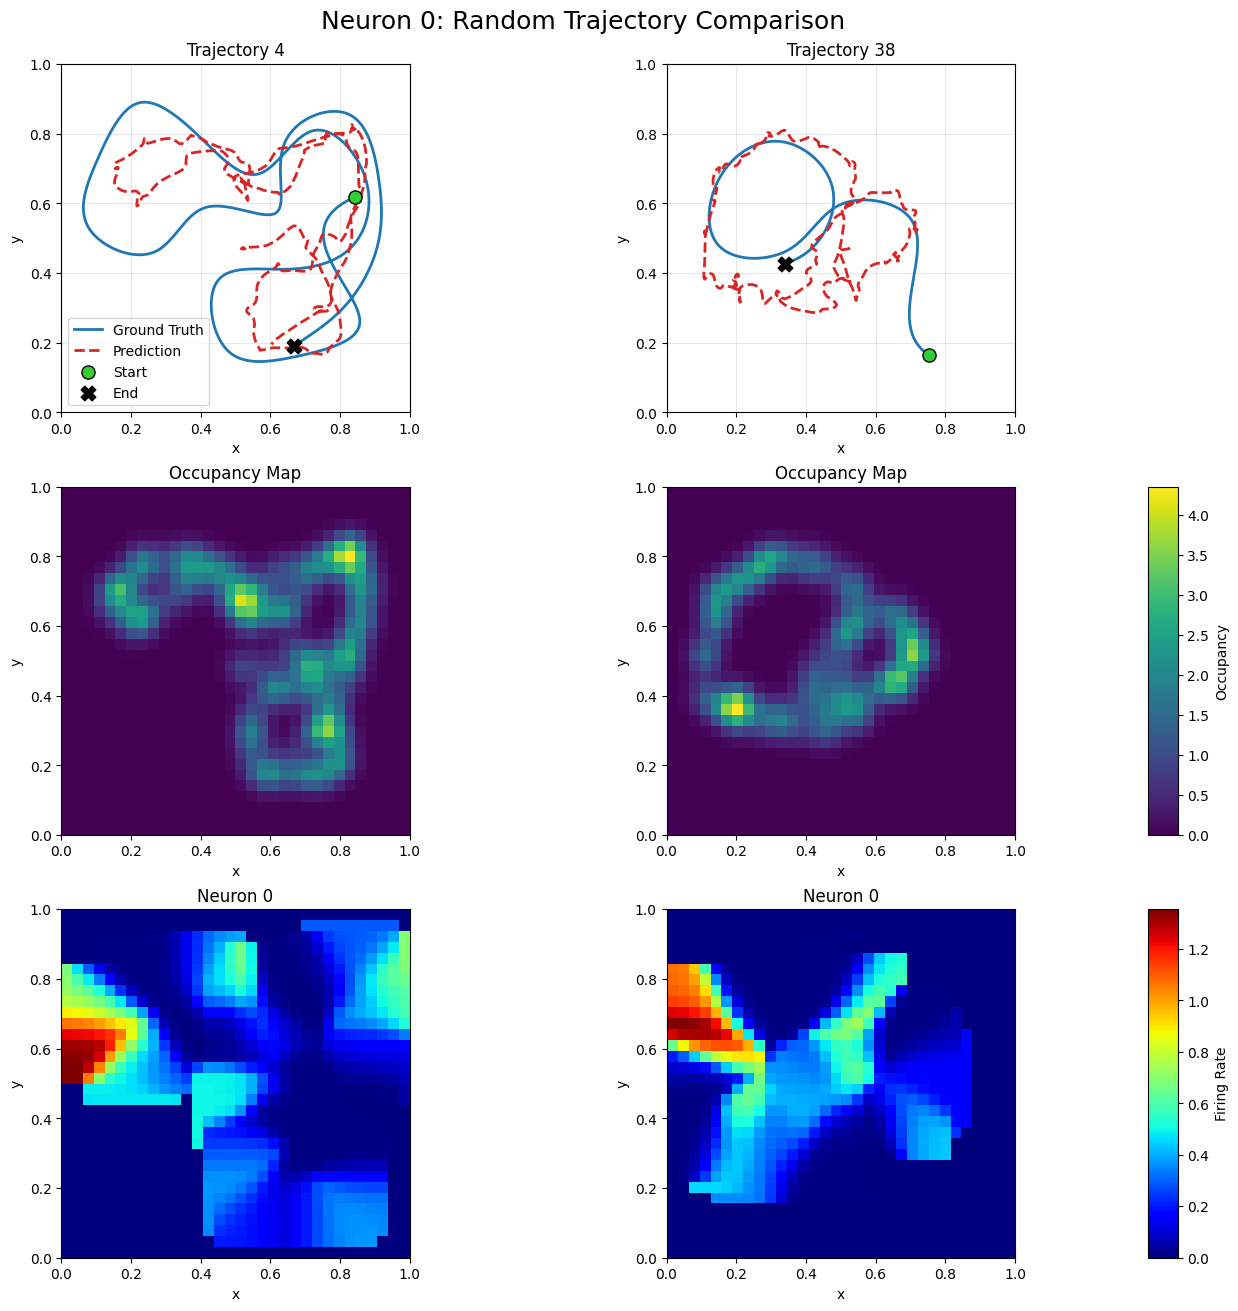


Trajectory 4


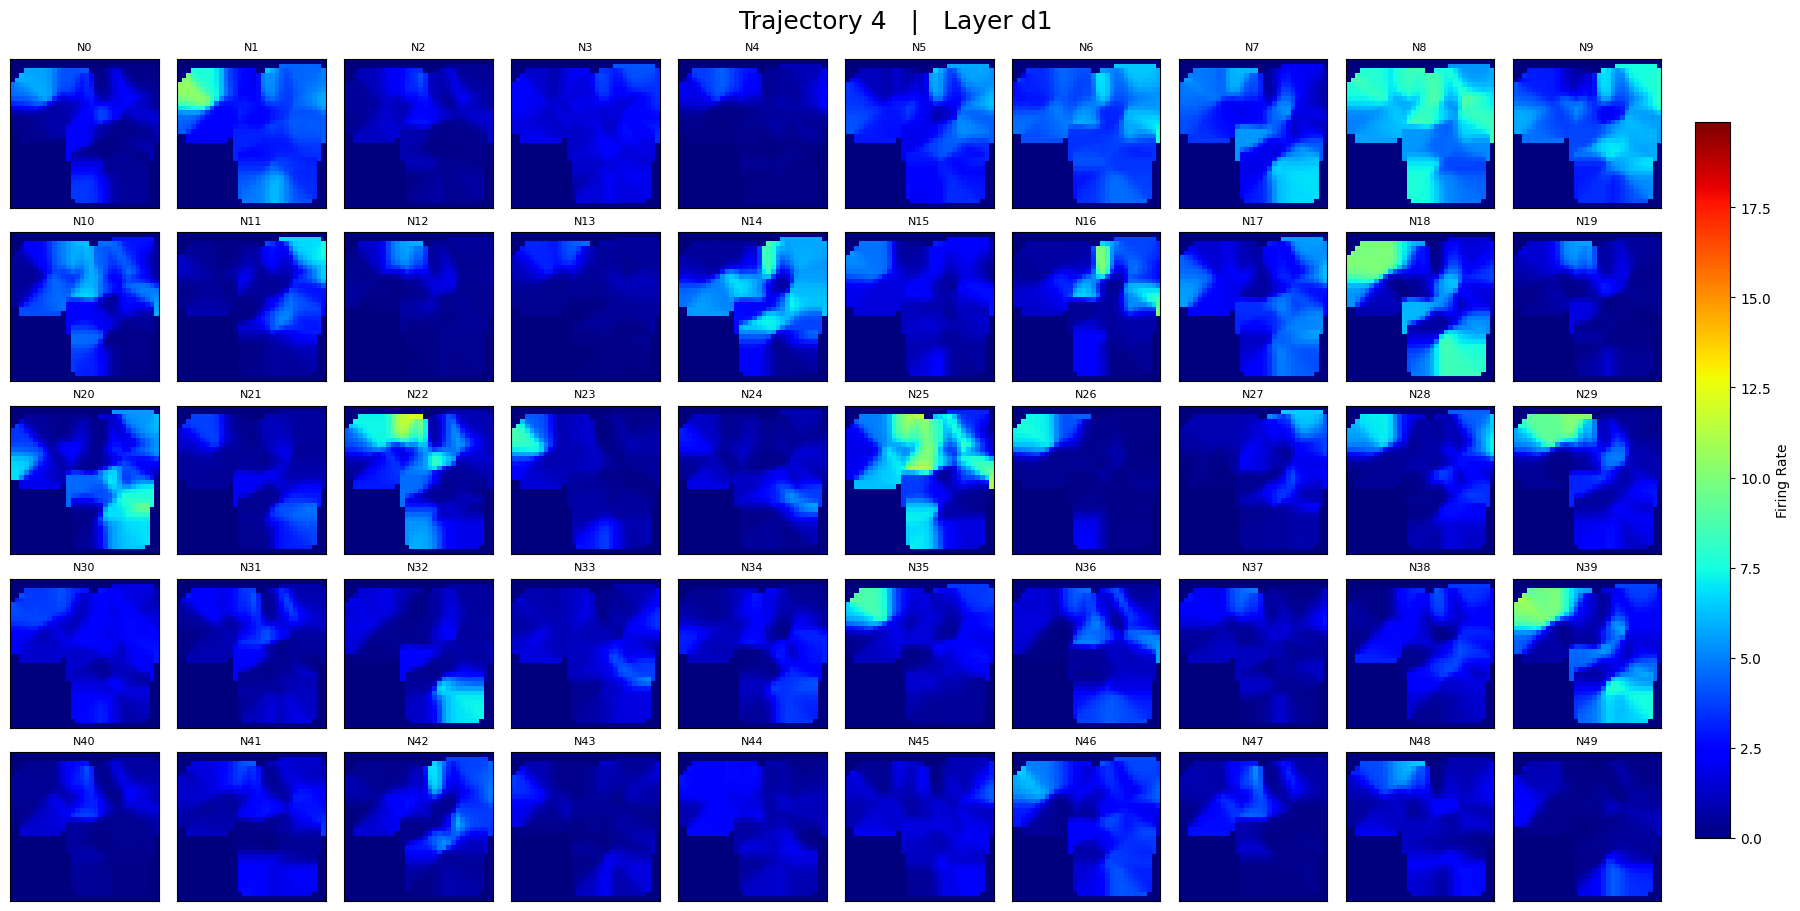

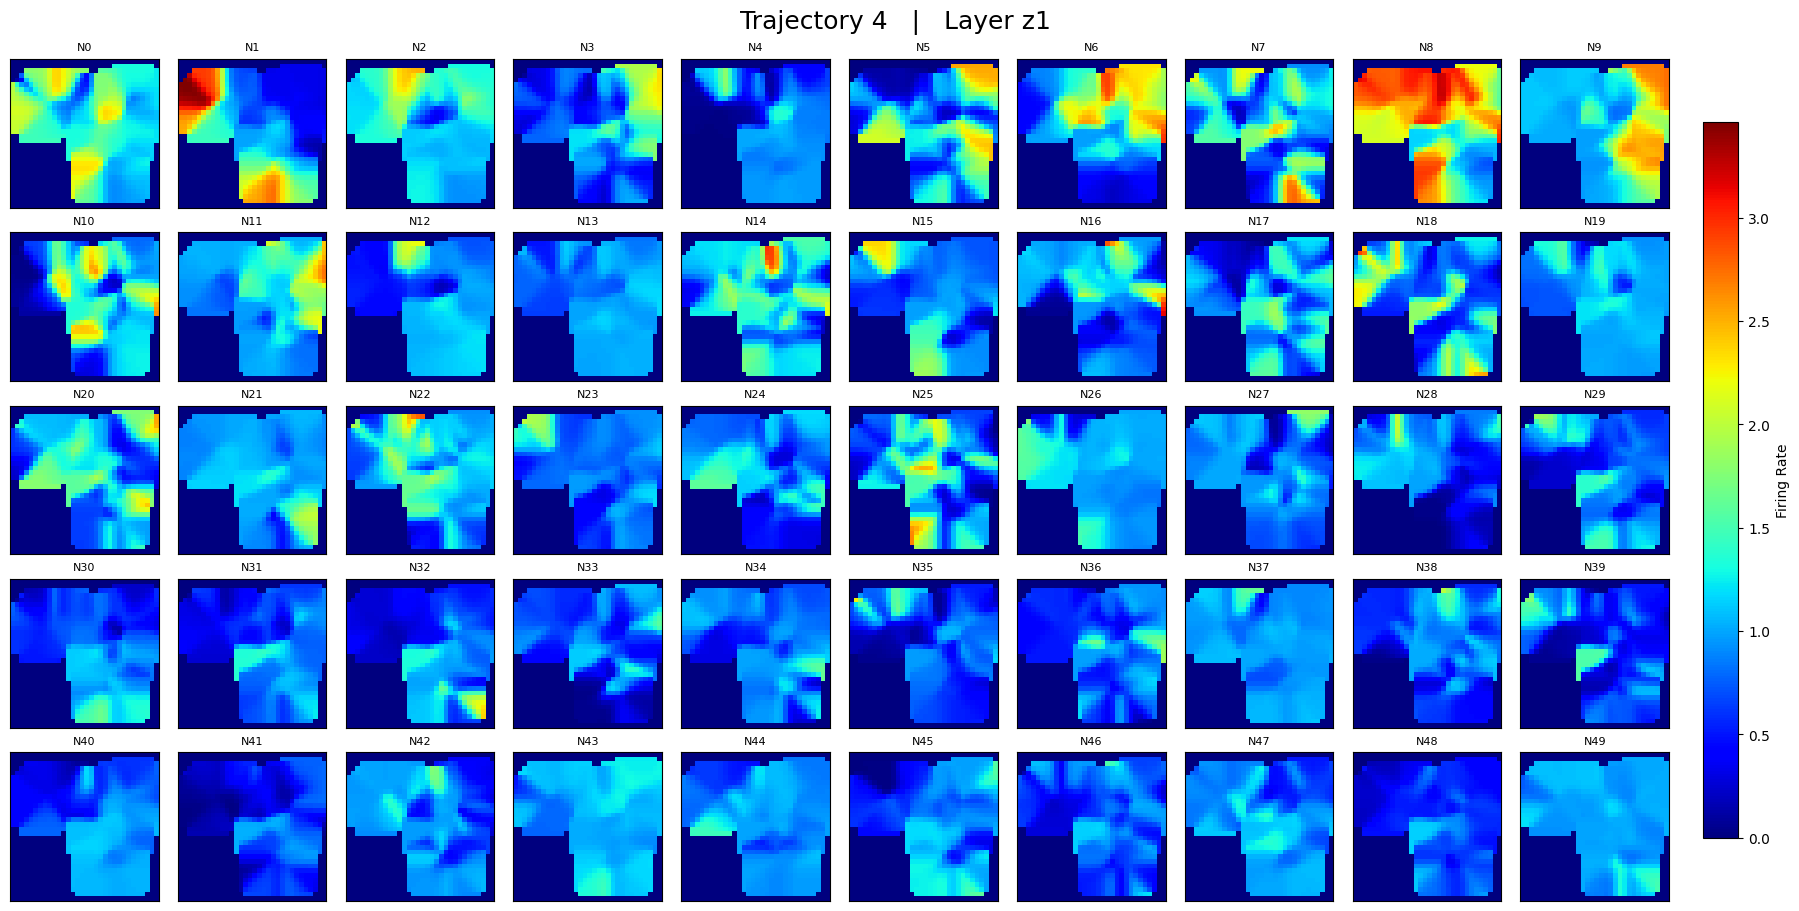

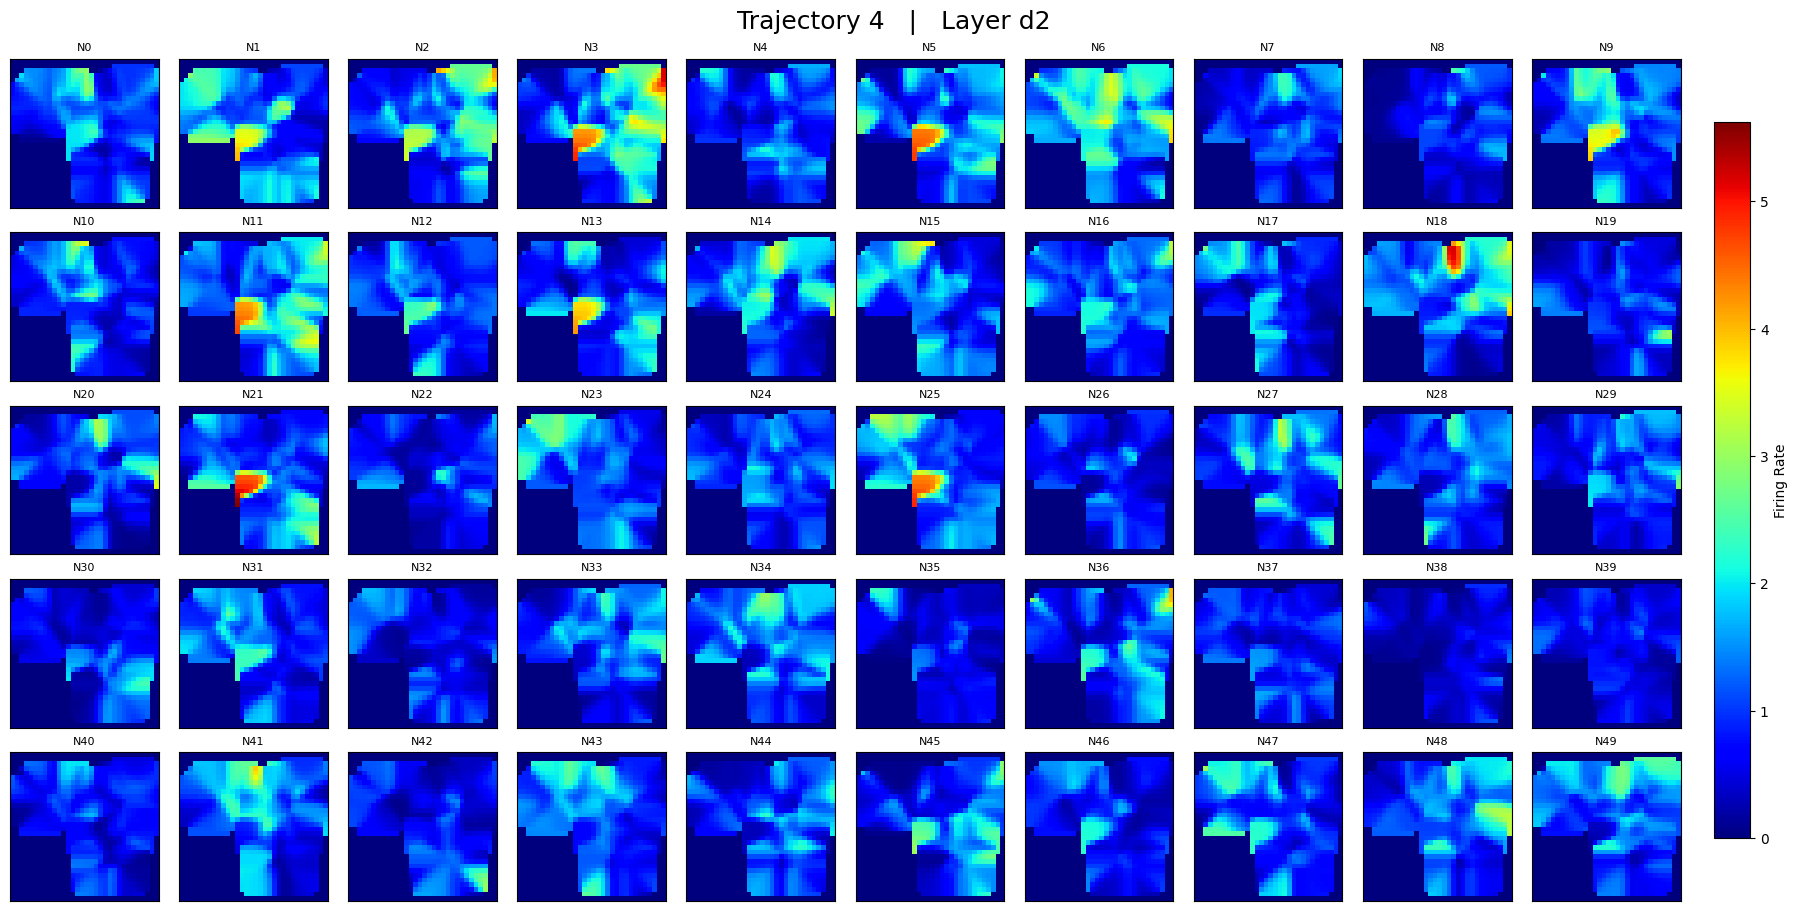

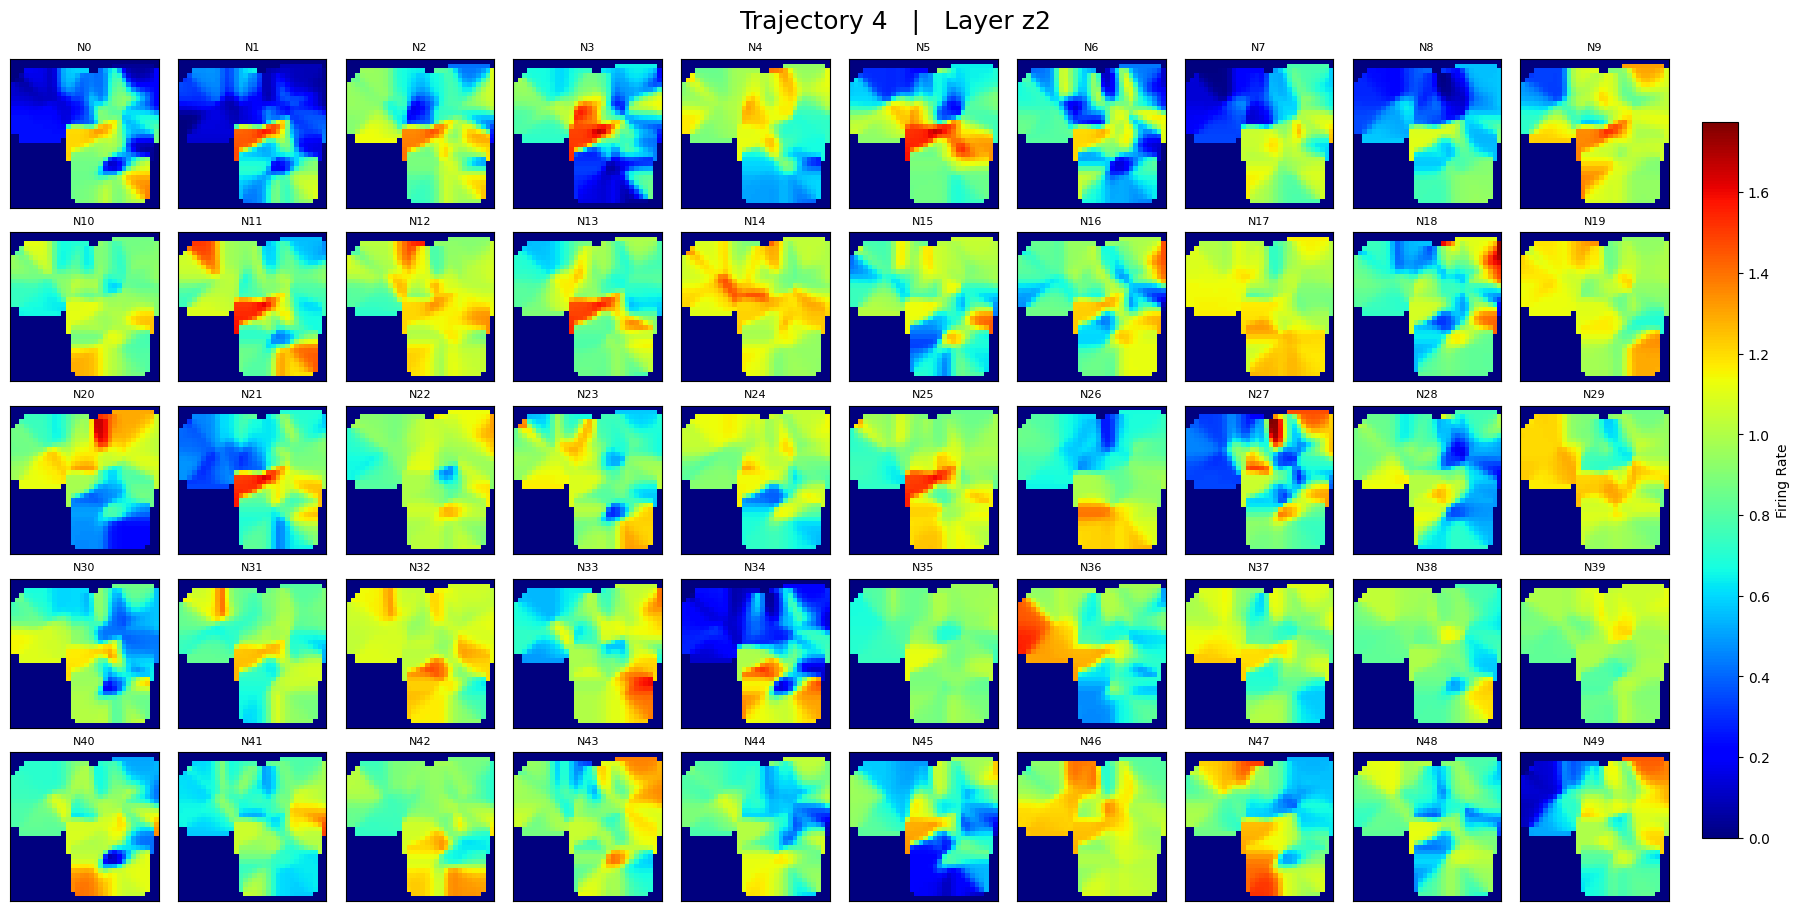

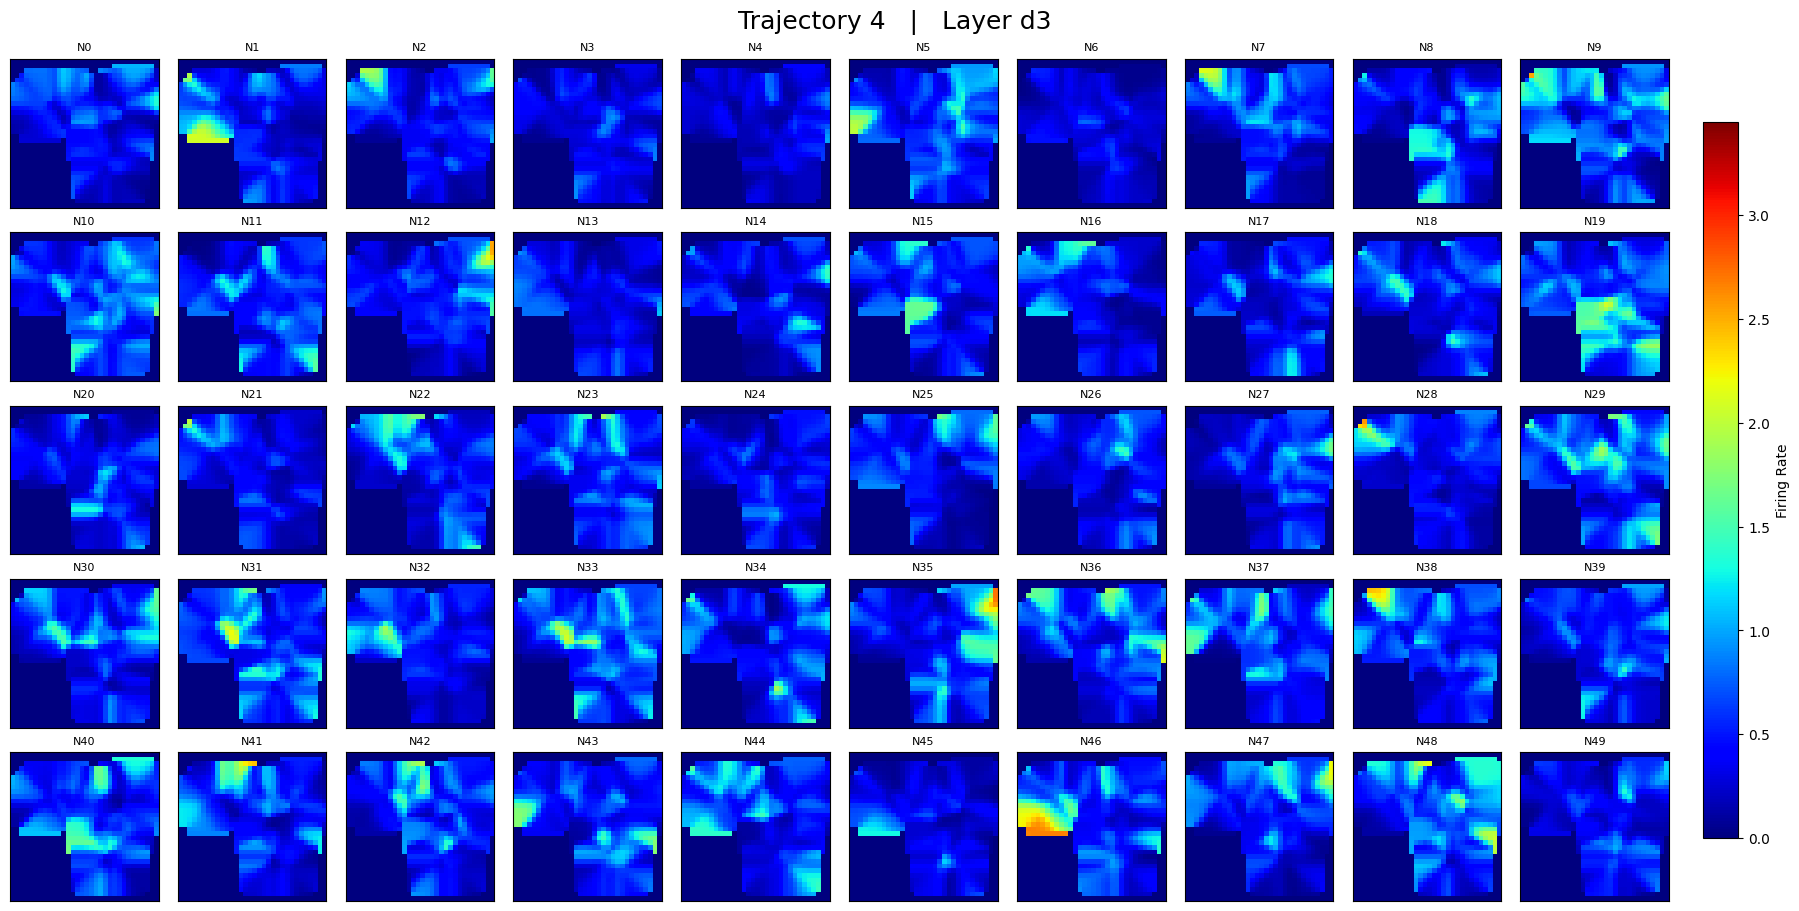

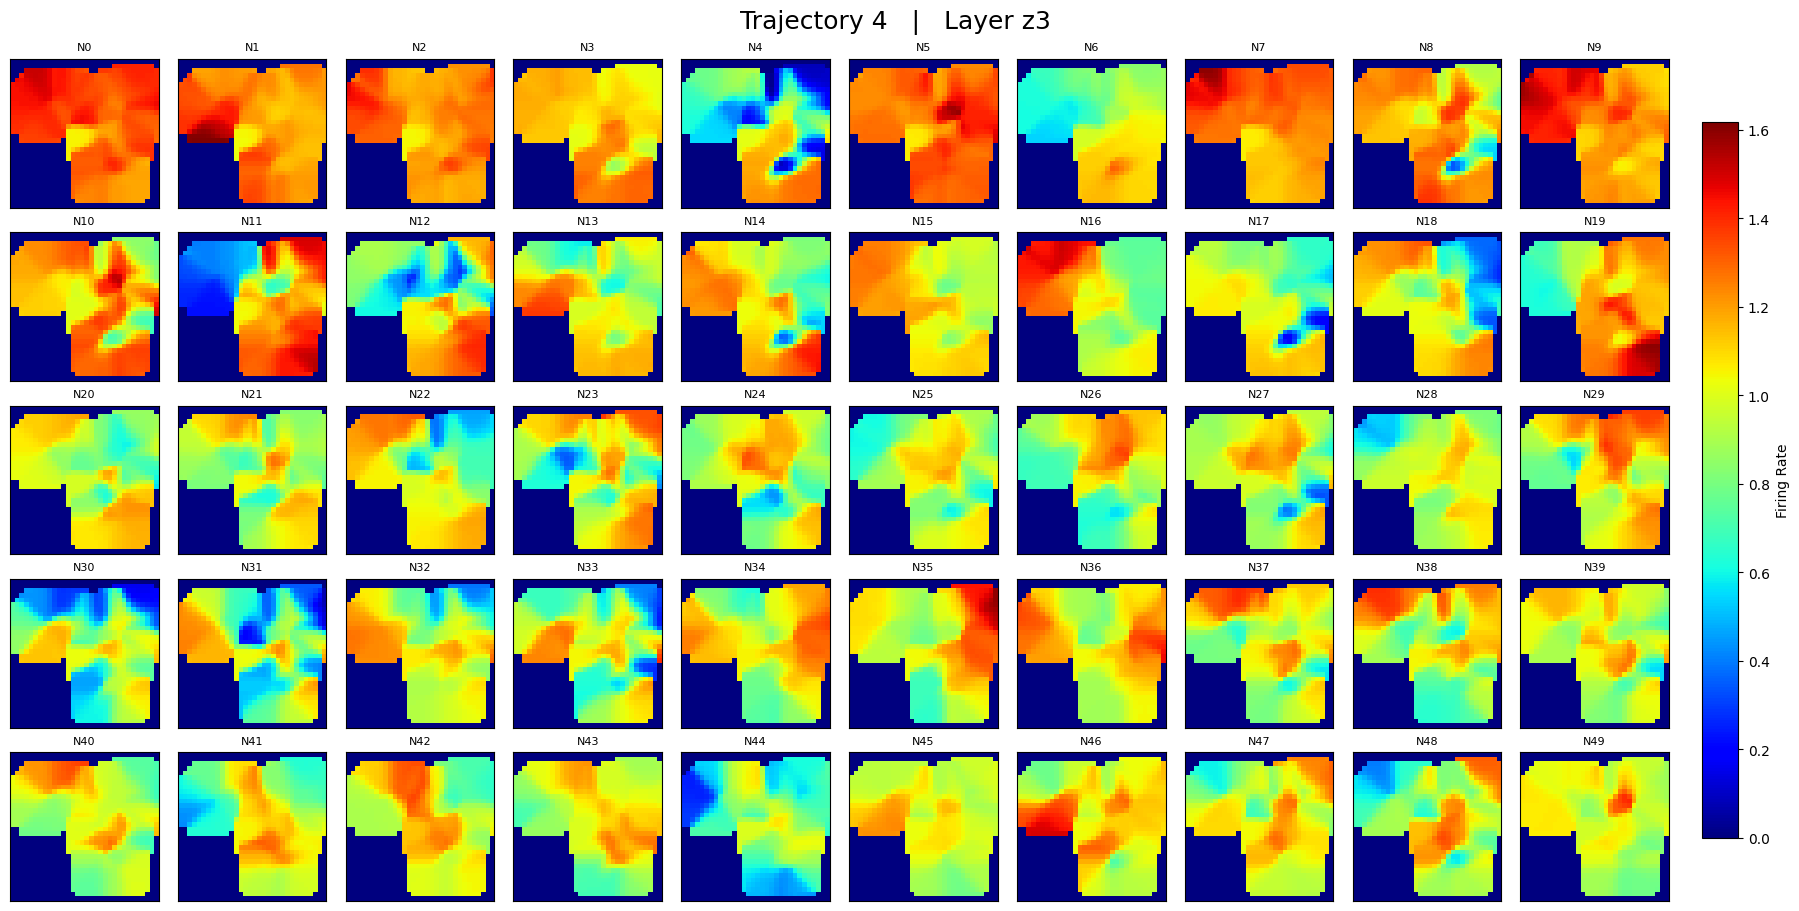

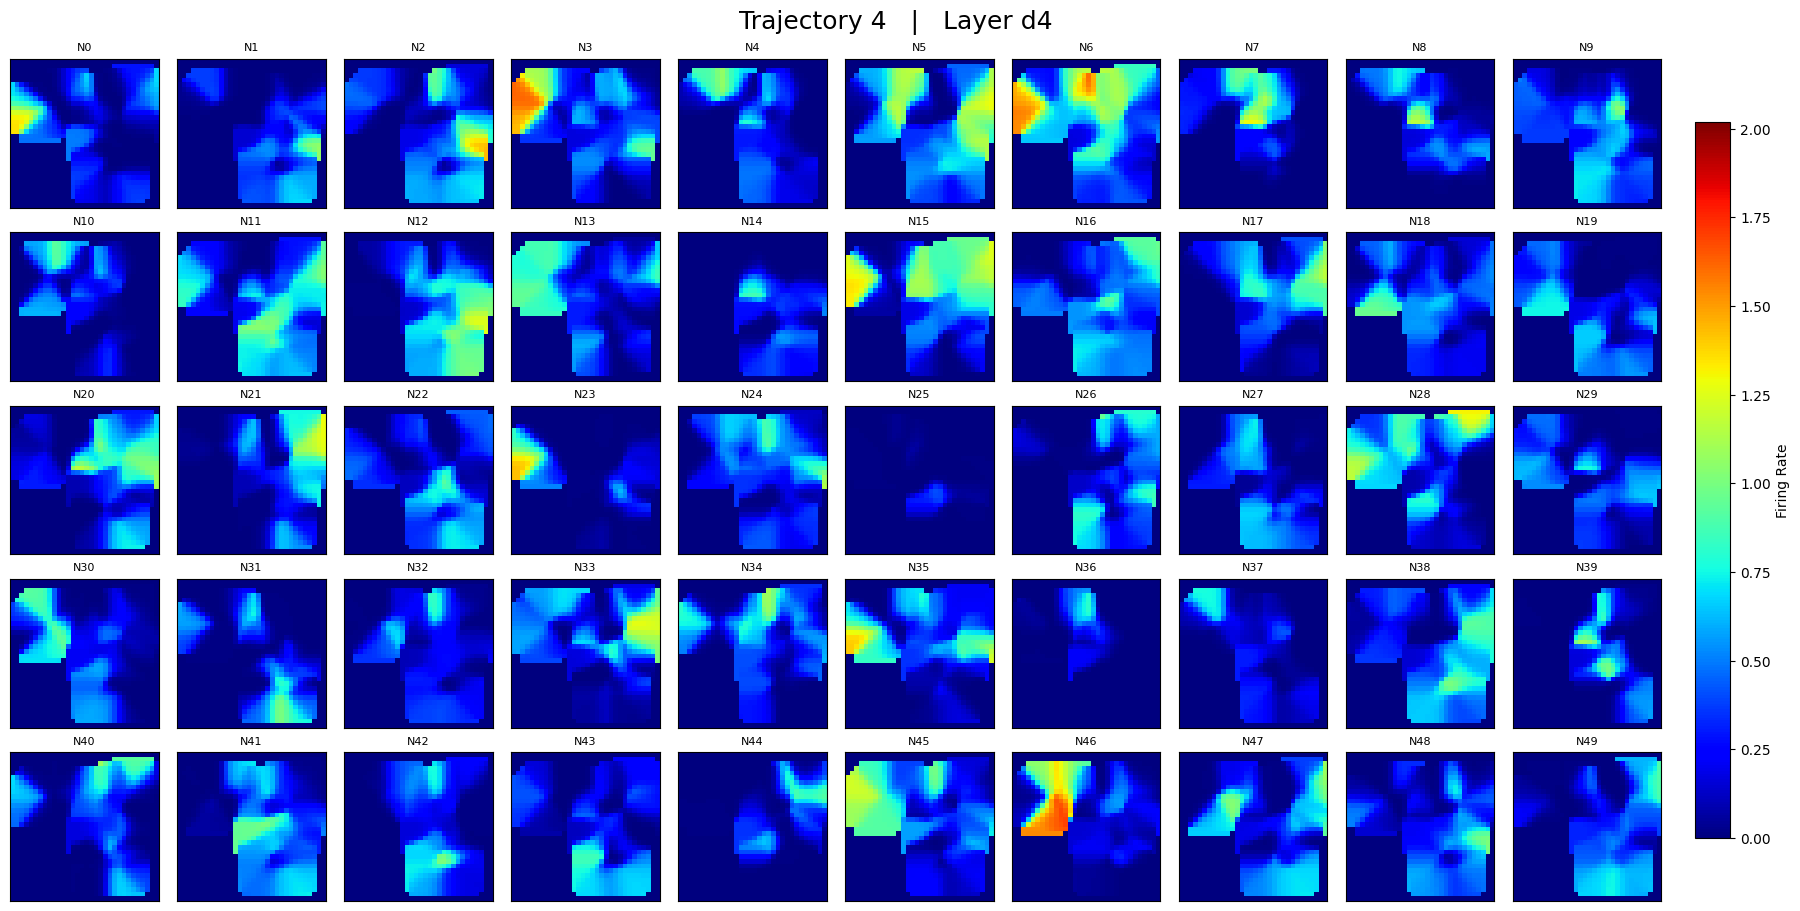


Trajectory 38


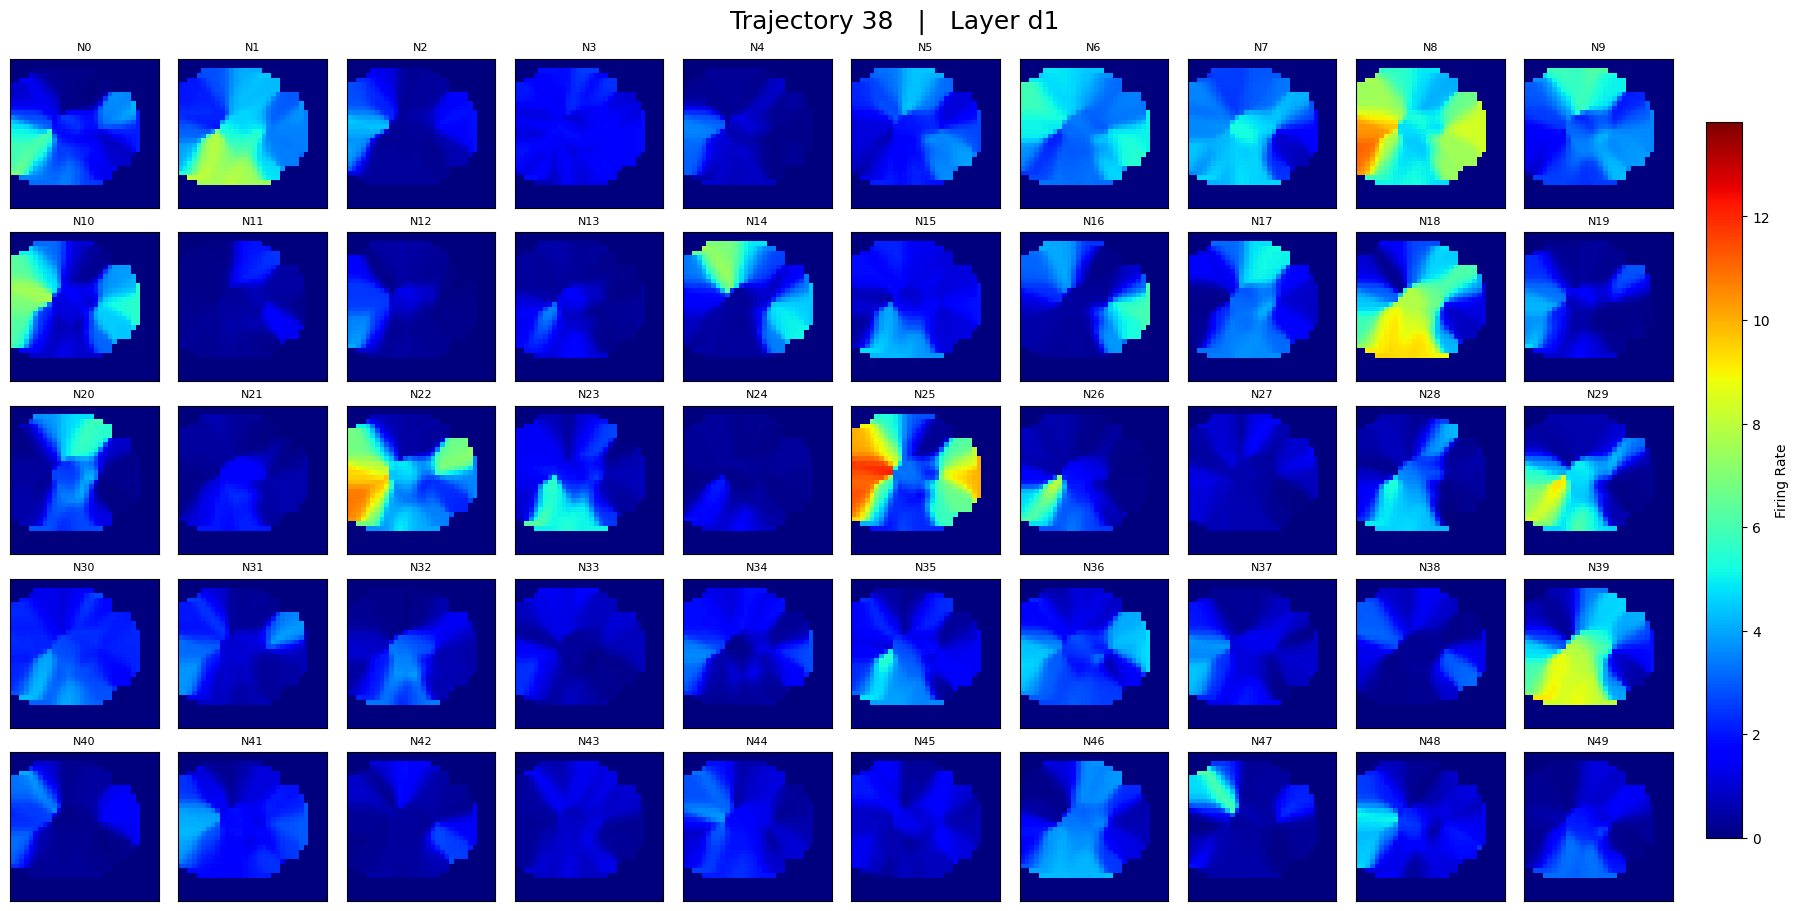

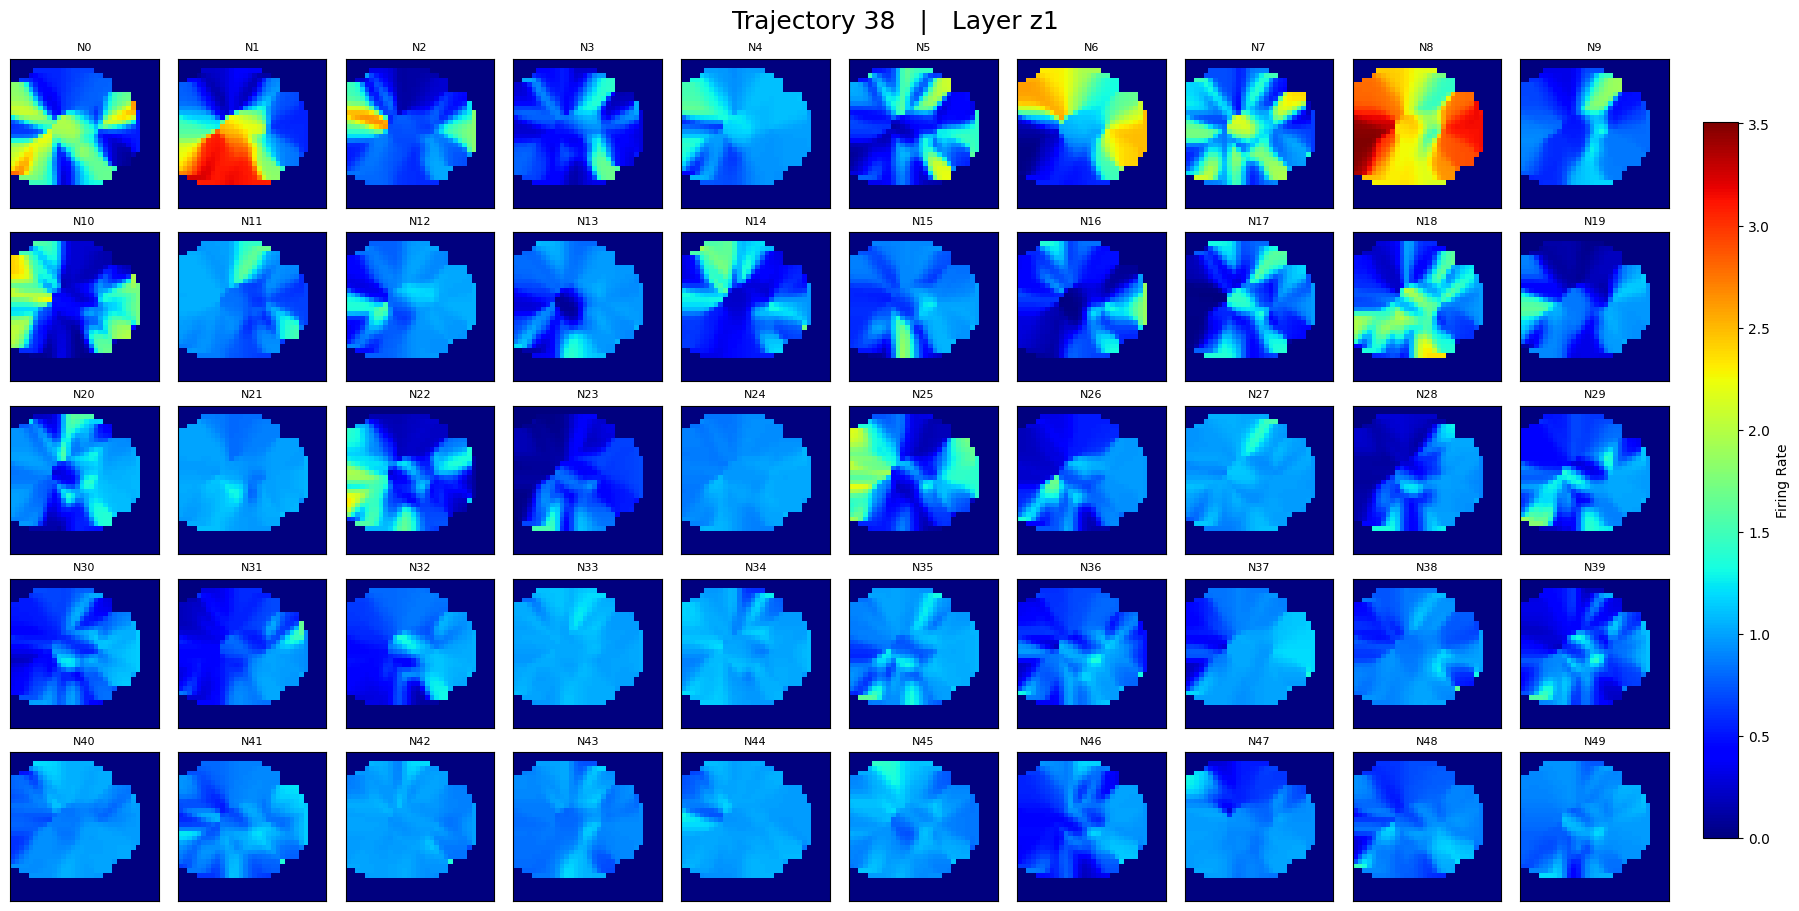

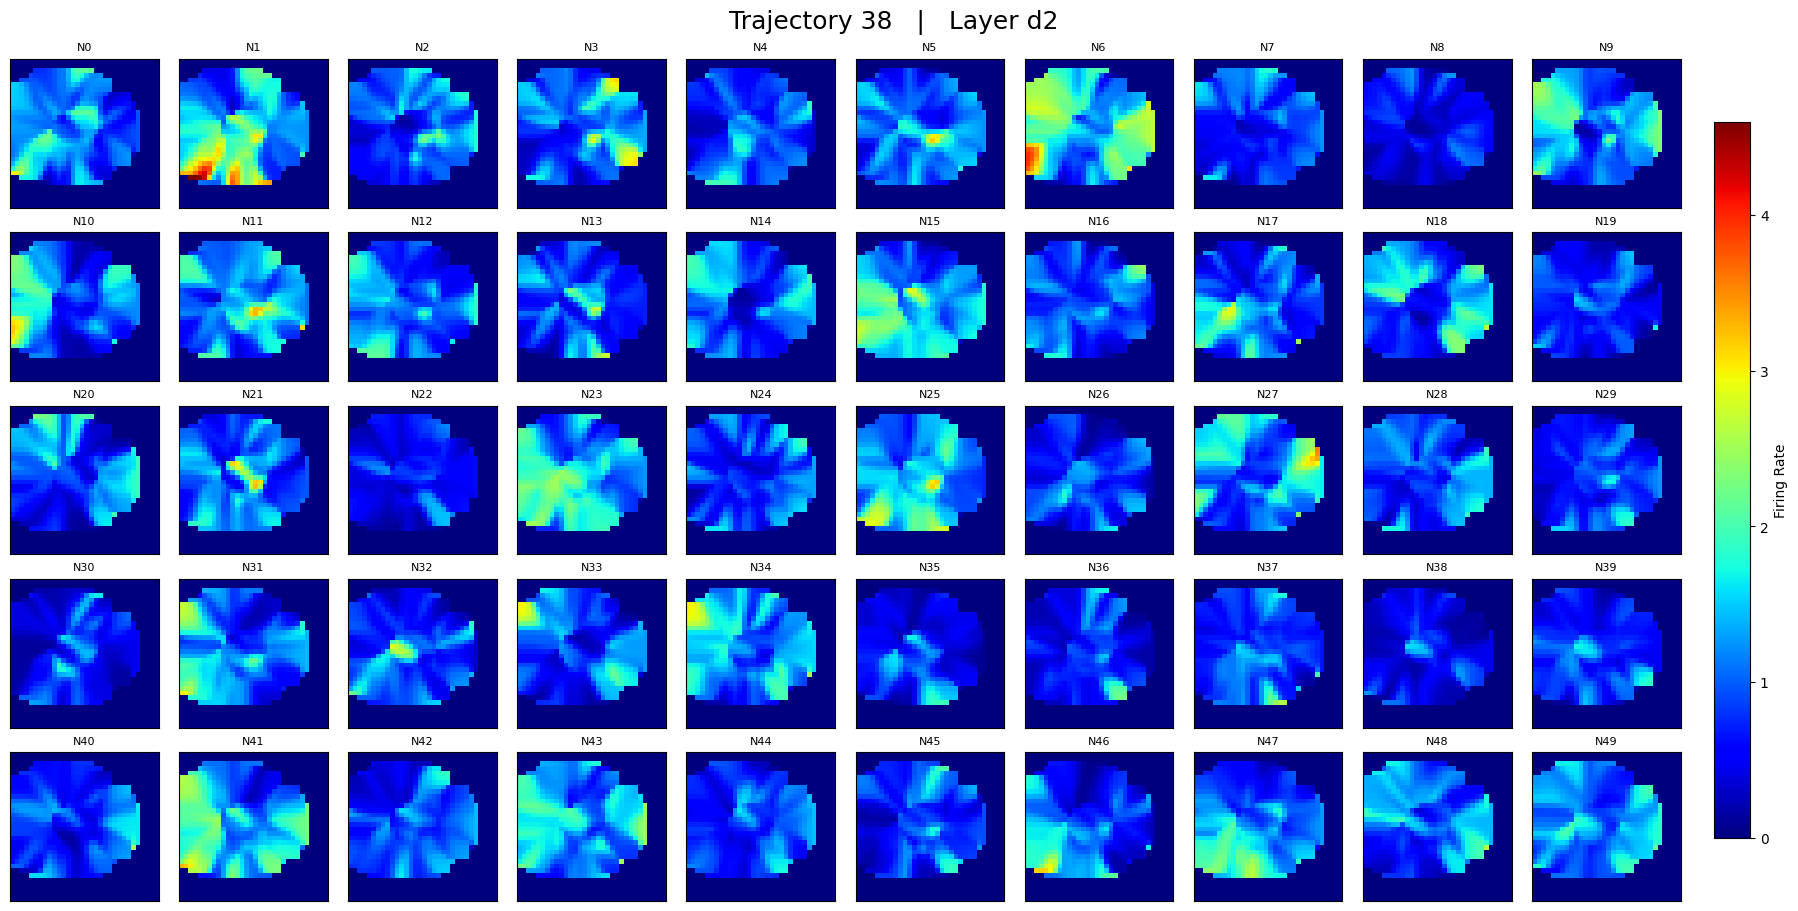

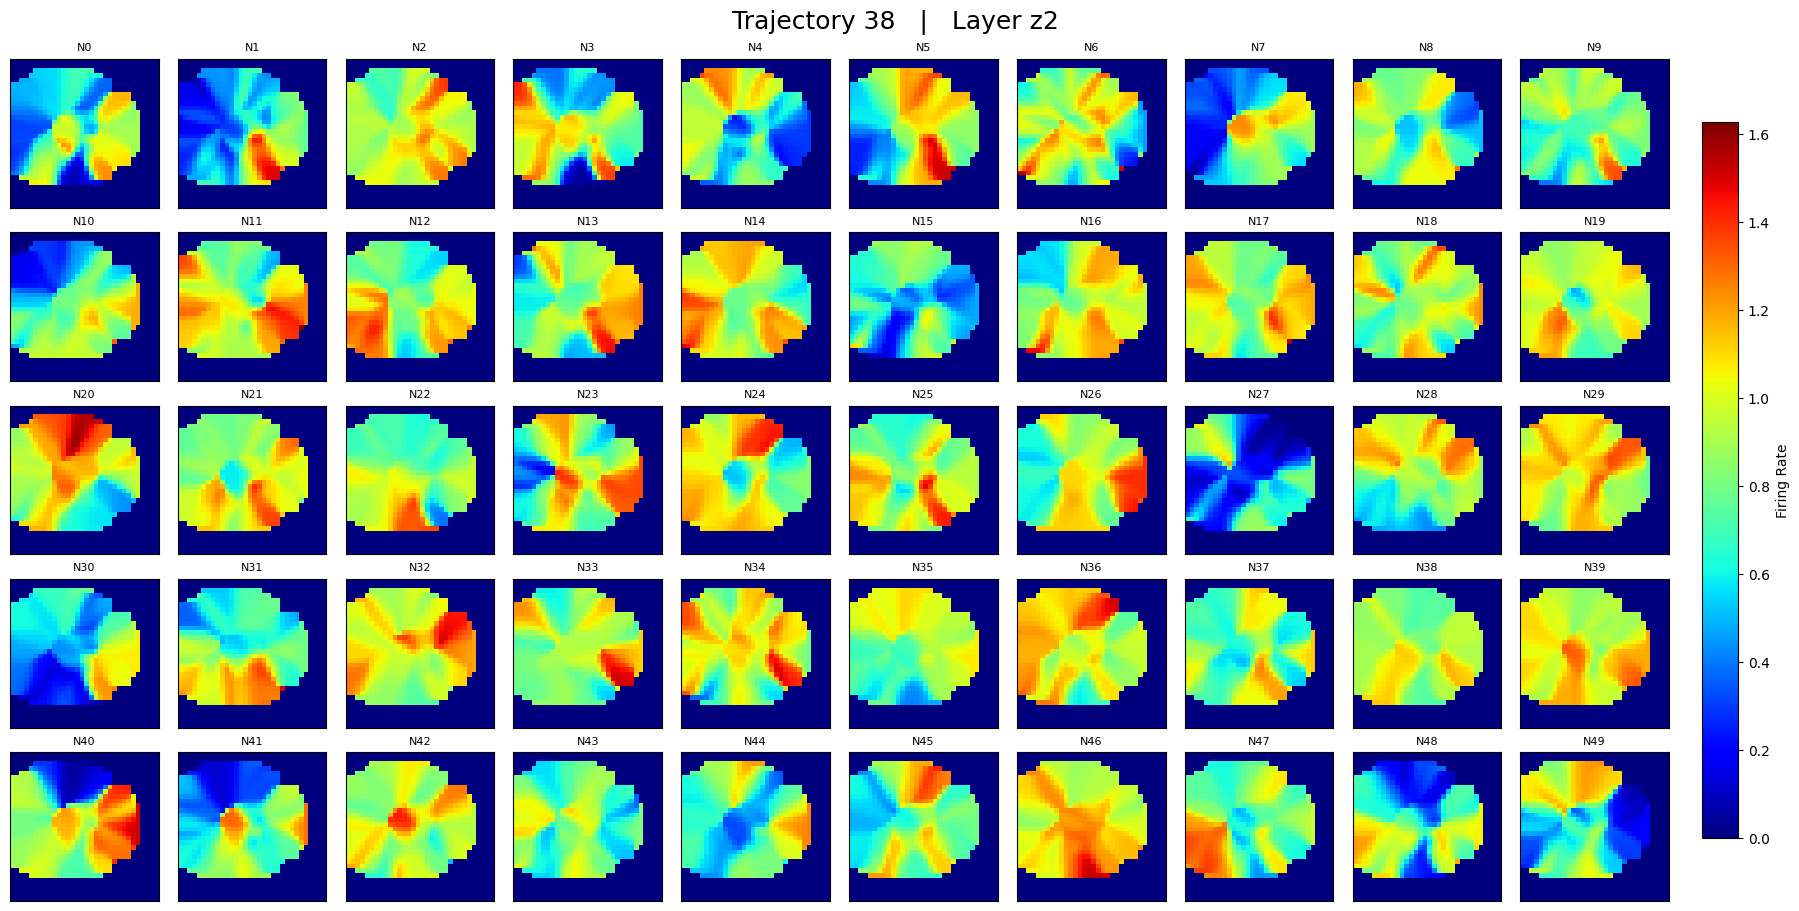

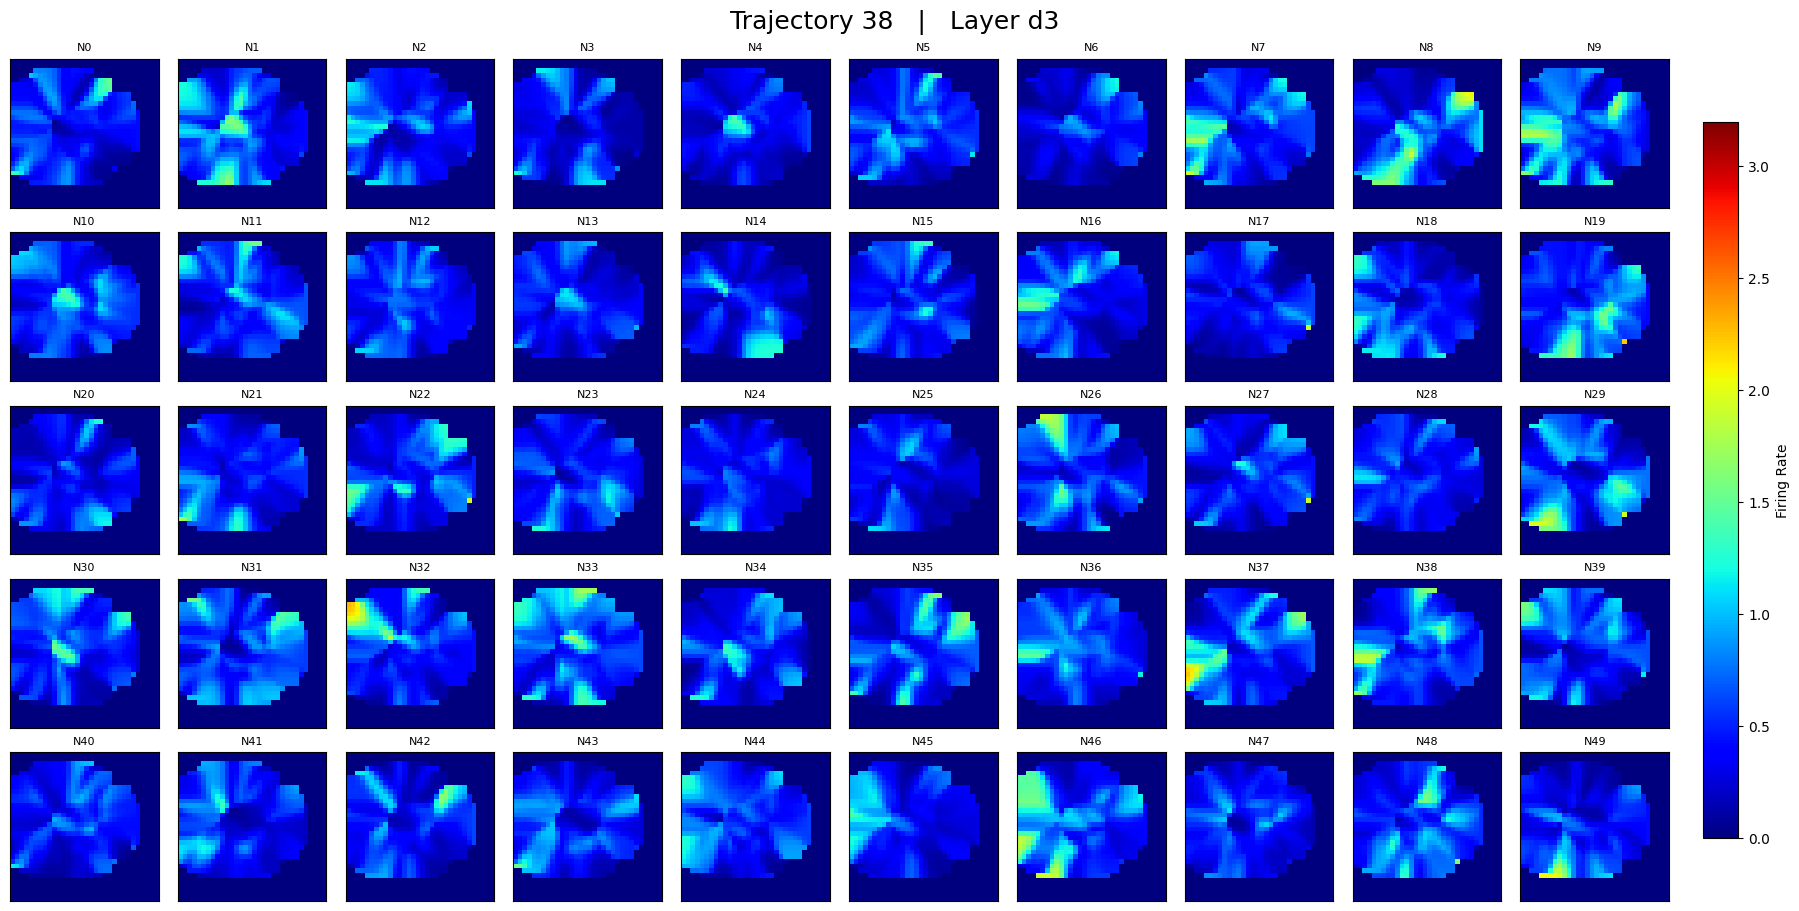

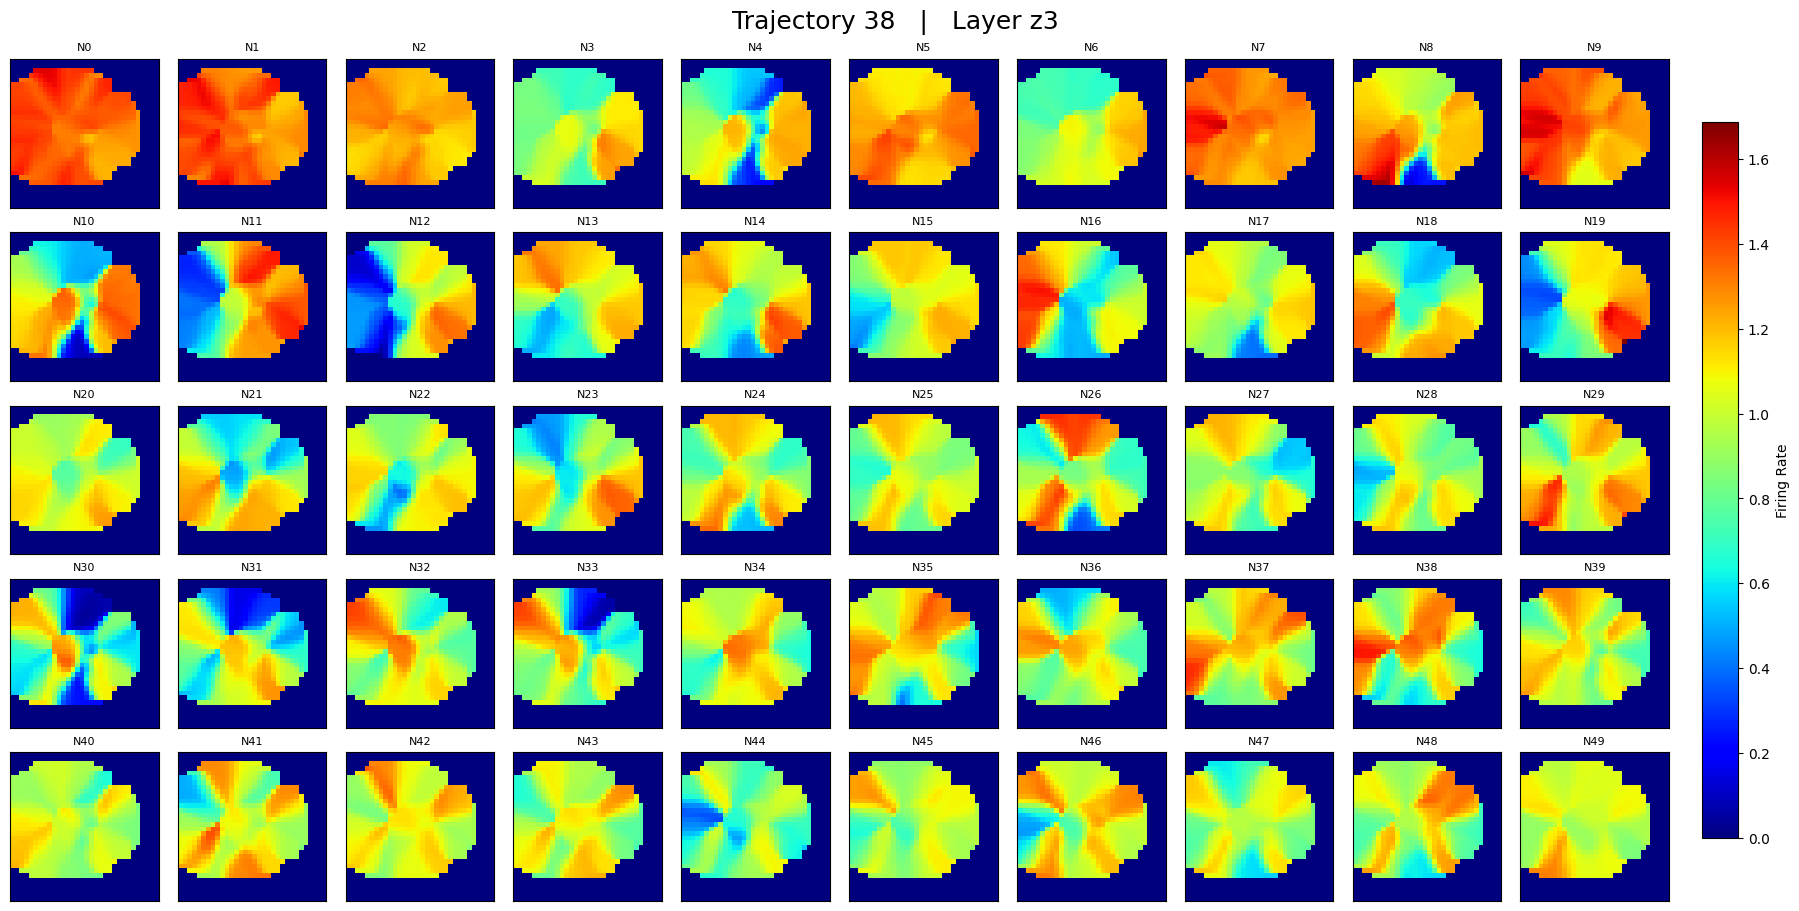

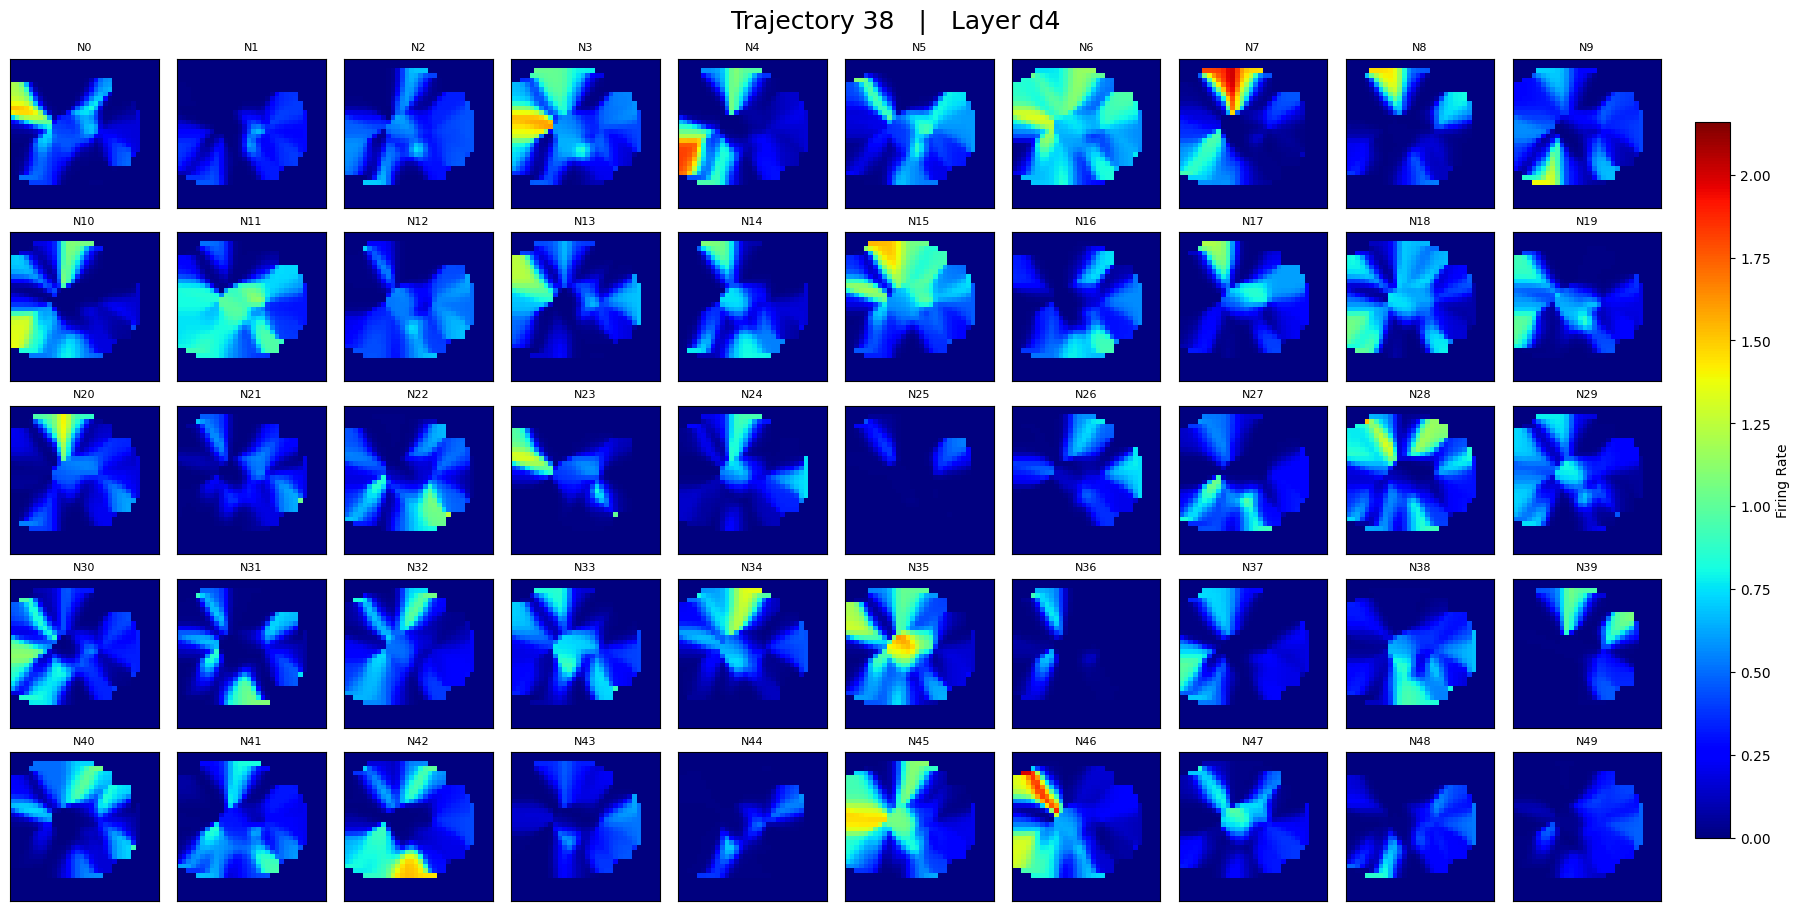

In [127]:
###########################################################
# Step 1
###########################################################

ground_truth, prediction, positions, activations = get_input_data(
    pkl_path,
    layer_name="d4",
)

###########################################################
# Step 2
###########################################################

rng = np.random.default_rng(42)

traj_ids = rng.choice(
    len(positions),
    size=2,
    replace=False,
)

###########################################################
# Step 3
###########################################################

plot_two_random_trajectories(
    ground_truth,
    prediction,
    positions,
    activations,
    neuron_idx=0,
    seed=42,
)

###########################################################
# Step 4
###########################################################

plot_all_layers_two_trajectories(
    pkl_path,
    traj_ids,
)